In [1]:
!nvidia-smi

Mon Aug 10 12:53:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install transformers torch pillow -q

In [3]:
import torch
from transformers import AutoImageProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
model = AutoModel.from_pretrained("facebook/dinov2-base").to(device)
model.eval()

print("Model loaded on:", device)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model loaded on: cuda


In [4]:
!pip install pymupdf -q

import fitz  # PyMuPDF

def pdf_to_image(pdf_path, output_path):
    doc = fitz.open(pdf_path)
    page = doc[0]  # first page
    pix = page.get_pixmap(dpi=150)
    pix.save(output_path)
    doc.close()
    print("Saved:", output_path)

pdf_to_image("0001 (1).pdf", "invoice_a.png")
pdf_to_image("0001 (4).pdf", "invoice_b.png")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 62.1 MB/s eta 0:00:00
Saved: invoice_a.png
Saved: invoice_b.png


In [6]:
from PIL import Image
import torch.nn.functional as F

def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :]

emb_a = get_embedding("invoice_a.png")
emb_b = get_embedding("invoice_b.png")

similarity = F.cosine_similarity(emb_a, emb_b).item()
print("Cosine similarity:", round(similarity, 4))

Cosine similarity: 0.8151


In [7]:
!pip install datasets -q

from datasets import load_dataset

ds = load_dataset("mathieu1256/FATURA2-invoices", split="train")
print(ds)
print(ds[0])

README.md:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  293MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 50.1MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8600 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1400 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'ner_tags', 'bboxes', 'tokens', 'id'],
    num_rows: 8600
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=595x841 at 0x7E3A2B3BF890>, 'ner_tags': [10, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 3, 3, 3, 13, 13, 13, 4, 4, 4, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 6, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 11], 'bboxes': [[22, 279, 538, 369], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [313, 124, 502, 208], [31

In [8]:
for i in [0, 1, 2, 500, 3000]:
    print(ds[i]["id"])


6437
1573
7457
2607
1917


In [9]:
!wget -q "https://zenodo.org/records/8261508/files/FATURA.zip?download=1" -O FATURA.zip
!unzip -q FATURA.zip -d FATURA

In [10]:
import os

for root, dirs, files in os.walk("FATURA"):
    print(root, "|", len(files), "files")
    if files:
        print("   sample:", files[:3])

FATURA | 0 files
FATURA/invoices_dataset_final | 4 files
   sample: ['strat1_test.csv', 'Strat2_Split.txt', 'strat1_dev.csv']
FATURA/invoices_dataset_final/Annotations | 0 files
FATURA/invoices_dataset_final/Annotations/layoutlm_HF_format | 10000 files
   sample: ['Template17_Instance106_hugg_train.json', 'Template33_Instance31_hugg_train.json', 'Template16_Instance172_hugg_train.json']
FATURA/invoices_dataset_final/Annotations/COCO_compatible_format | 10000 files
   sample: ['Template33_Instance87_coco_train.json', 'Template16_Instance0_coco_train.json', 'Template41_Instance28_coco_train.json']
FATURA/invoices_dataset_final/Annotations/.virtual_documents | 0 files
FATURA/invoices_dataset_final/Annotations/Original_Format | 10000 files
   sample: ['Template21_Instance167.json', 'Template46_Instance190.json', 'Template29_Instance17.json']
FATURA/invoices_dataset_final/images | 10000 files
   sample: ['Template21_Instance99.jpg', 'Template47_Instance142.jpg', 'Template49_Instance97.jpg']

In [11]:
import os, collections, random

IMG_DIR = "FATURA/invoices_dataset_final/images"

groups = collections.defaultdict(list)
for fname in os.listdir(IMG_DIR):
    template = fname.split("_")[0]        # "Template21_Instance99.jpg" → "Template21"
    groups[template].append(os.path.join(IMG_DIR, fname))

print("Template families:", len(groups))
print("Example counts:", {t: len(groups[t]) for t in list(groups)[:3]})

Template families: 50
Example counts: {'Template21': 200, 'Template47': 200, 'Template49': 200}


In [12]:
random.seed(42)   # so results are reproducible
templates = list(groups.keys())

# 20 SAME-template pairs (2 random images from one family)
same_pairs = []
for t in random.sample(templates, 20):
    a, b = random.sample(groups[t], 2)
    same_pairs.append((a, b))

# 20 DIFFERENT-template pairs (1 image each from 2 different families)
diff_pairs = []
for t1, t2 in [random.sample(templates, 2) for _ in range(20)]:
    diff_pairs.append((random.choice(groups[t1]), random.choice(groups[t2])))

def pair_similarity(path_a, path_b):
    return F.cosine_similarity(get_embedding(path_a), get_embedding(path_b)).item()

same_scores = [pair_similarity(a, b) for a, b in same_pairs]
diff_scores = [pair_similarity(a, b) for a, b in diff_pairs]

print("SAME-template  → min:", round(min(same_scores), 3),
      " max:", round(max(same_scores), 3),
      " avg:", round(sum(same_scores)/20, 3))
print("DIFF-template  → min:", round(min(diff_scores), 3),
      " max:", round(max(diff_scores), 3),
      " avg:", round(sum(diff_scores)/20, 3))

SAME-template  → min: 0.947  max: 0.997  avg: 0.981
DIFF-template  → min: 0.725  max: 0.964  avg: 0.864


In [13]:
scored_diff = sorted(zip(diff_scores, diff_pairs), reverse=True)
for score, (a, b) in scored_diff[:3]:
    print(round(score, 3), "|", os.path.basename(a), "vs", os.path.basename(b))

0.964 | Template25_Instance153.jpg vs Template34_Instance82.jpg
0.937 | Template22_Instance16.jpg vs Template9_Instance118.jpg
0.933 | Template5_Instance194.jpg vs Template41_Instance142.jpg


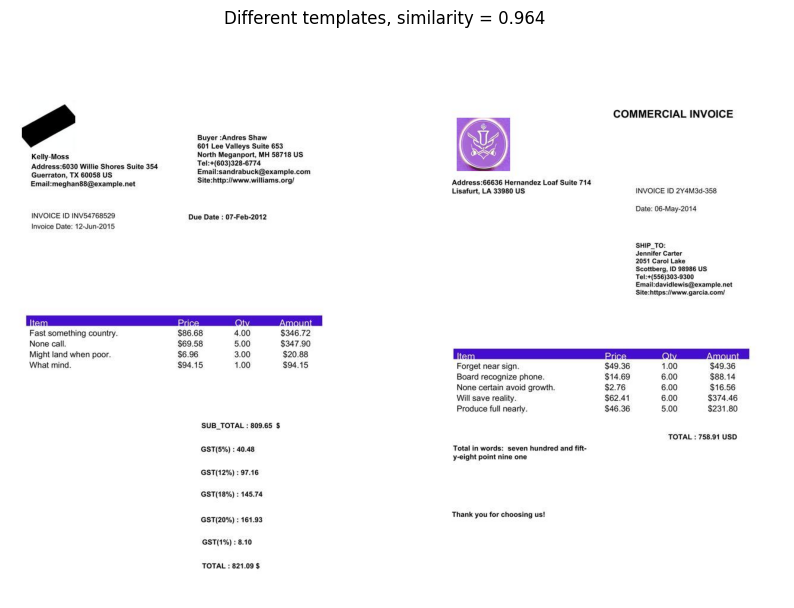

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

score, (a, b) = scored_diff[0]
fig, axes = plt.subplots(1, 2, figsize=(10, 7))
axes[0].imshow(Image.open(a)); axes[0].axis("off")
axes[1].imshow(Image.open(b)); axes[1].axis("off")
plt.suptitle(f"Different templates, similarity = {score:.3f}")
plt.show()

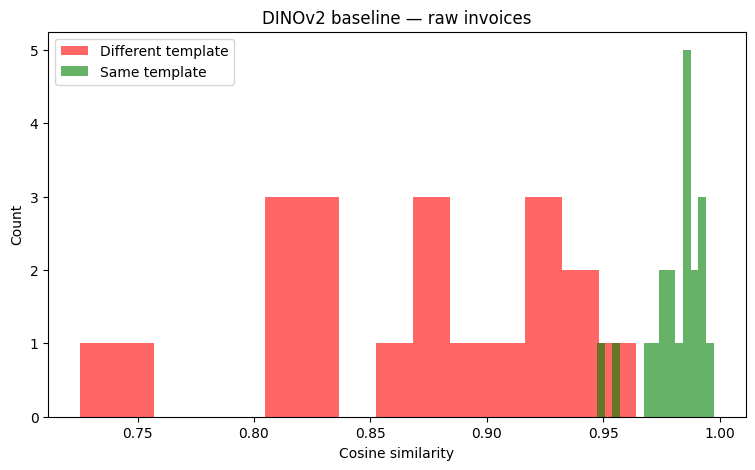

In [15]:
plt.figure(figsize=(9, 5))
plt.hist(diff_scores, bins=15, alpha=0.6, label="Different template", color="red")
plt.hist(same_scores, bins=15, alpha=0.6, label="Same template", color="green")
plt.xlabel("Cosine similarity"); plt.ylabel("Count")
plt.title("DINOv2 baseline — raw invoices")
plt.legend(); plt.show()

In [16]:
import json

ann_path = "FATURA/invoices_dataset_final/Annotations/Original_Format/Template21_Instance99.json"
with open(ann_path) as f:
    ann = json.load(f)

print(type(ann))
print(str(ann)[:2000])

<class 'dict'>
{'TABLE': [[{'bbox': [[37.0, 289.88980000000004], [587.0, 235.8898]]}]], 'INVOICE_INFO': [], 'DATE': {'bbox': [[421.0, 512.4058], [561.736, 524.4058]], 'text': 'Invoice Date: 27-Jan-1999'}, 'DUE_DATE': {'bbox': [[36.0, 515.4058], [168.708, 527.4058]], 'text': 'Due Date : 28-Sep-2016'}, 'NUMBER': {'bbox': [[335.0, 784.4058], [471.716, 796.4058]], 'text': 'INVOICE ID 5Y1M5d-031'}, 'NOTE': {'bbox': [[39.0, 631.4058], [240.384, 643.4058]], 'text': 'Note:Total payment due in 14 days.'}, 'SELLER_ADDRESS': {'bbox': [[38.0, 687.0058], [233.40800000000002, 713.4058]], 'text': 'Address:045 David Walk Suite 362\nEast Robert, NV 70596 US'}, 'SELLER_NAME': {'bbox': [[38, 729], [135, 741]], 'text': 'Murphy-Gallegos'}, 'TAX': {'bbox': [[356.0, 120.4058], [522.704, 132.4058]], 'text': 'TAX:VAT (4.11%):  14.98 USD'}, 'TITLE': {'bbox': [[304.0, 821.1638], [378.01599999999996, 839.1638]], 'text': 'INVOICE'}, 'TOTAL': {'bbox': [[437.0, 103.4058], [553.028, 115.4058]], 'text': 'TOTAL : 368.2

In [18]:
from PIL import Image, ImageDraw

ANN_DIR = "FATURA/invoices_dataset_final/Annotations/Original_Format"

def collect_bboxes(node):
    """Recursively find every 'bbox' in the annotation structure."""
    boxes = []
    if isinstance(node, dict):
        for key, val in node.items():
            if key == "bbox":
                boxes.append(val)
            else:
                boxes.extend(collect_bboxes(val))
    elif isinstance(node, list):
        for item in node:
            boxes.extend(collect_bboxes(item))
    return boxes

def mask_invoice(image_path):
    """Open invoice, paint all annotated regions black, return skeleton."""
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    draw = ImageDraw.Draw(img)

    name = os.path.basename(image_path).replace(".jpg", ".json")
    with open(os.path.join(ANN_DIR, name)) as f:
        ann = json.load(f)

    for (x1, y1), (x2, y2) in collect_bboxes(ann):
        top    = H - max(y1, y2)   # flip y: PDF coords → image coords
        bottom = H - min(y1, y2)
        draw.rectangle([min(x1, x2), top, max(x1, x2), bottom], fill="black")
    return img

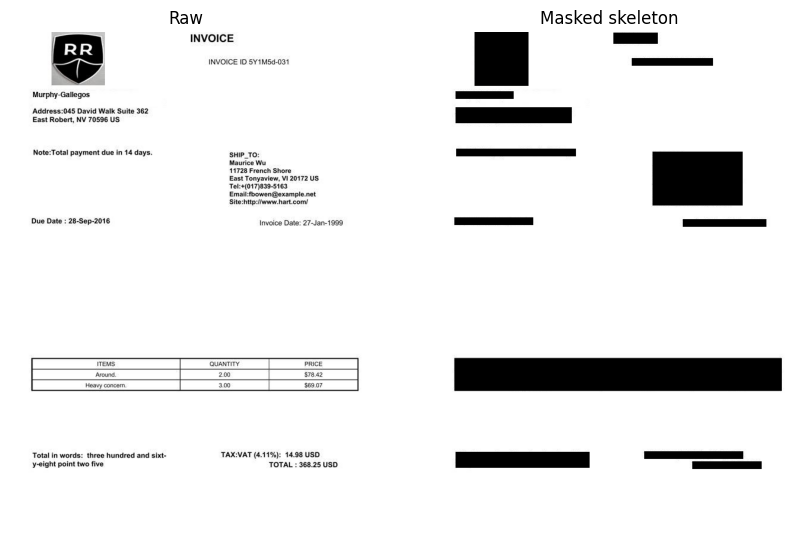

In [19]:
skeleton = mask_invoice(f"{IMG_DIR}/Template21_Instance99.jpg")

fig, axes = plt.subplots(1, 2, figsize=(10, 7))
axes[0].imshow(Image.open(f"{IMG_DIR}/Template21_Instance99.jpg")); axes[0].axis("off"); axes[0].set_title("Raw")
axes[1].imshow(skeleton); axes[1].axis("off"); axes[1].set_title("Masked skeleton")
plt.show()

In [20]:
def pair_similarity_masked(path_a, path_b):
    emb_a = get_embedding_from_image(mask_invoice(path_a))
    emb_b = get_embedding_from_image(mask_invoice(path_b))
    return F.cosine_similarity(emb_a, emb_b).item()

def get_embedding_from_image(image):
    """Same as get_embedding, but takes an already-open PIL image."""
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :]

same_scores_m = [pair_similarity_masked(a, b) for a, b in same_pairs]
diff_scores_m = [pair_similarity_masked(a, b) for a, b in diff_pairs]

print("MASKED SAME → min:", round(min(same_scores_m), 3),
      " max:", round(max(same_scores_m), 3),
      " avg:", round(sum(same_scores_m)/20, 3))
print("MASKED DIFF → min:", round(min(diff_scores_m), 3),
      " max:", round(max(diff_scores_m), 3),
      " avg:", round(sum(diff_scores_m)/20, 3))

MASKED SAME → min: 0.92  max: 0.998  avg: 0.98
MASKED DIFF → min: 0.815  max: 0.946  avg: 0.87


In [21]:
from sklearn.metrics import roc_auc_score

labels = [1]*20 + [0]*20
auc_raw    = roc_auc_score(labels, same_scores   + diff_scores)
auc_masked = roc_auc_score(labels, same_scores_m + diff_scores_m)

print("AUC raw:   ", round(auc_raw, 4))
print("AUC masked:", round(auc_masked, 4))

AUC raw:    0.995
AUC masked: 0.995


In [22]:
random.seed(123)   # new seed = new, unseen pairs

same_pairs_big, diff_pairs_big = [], []
for _ in range(150):
    t = random.choice(templates)
    same_pairs_big.append(tuple(random.sample(groups[t], 2)))
    t1, t2 = random.sample(templates, 2)
    diff_pairs_big.append((random.choice(groups[t1]), random.choice(groups[t2])))

same_big = [pair_similarity(a, b) for a, b in same_pairs_big]
diff_big = [pair_similarity(a, b) for a, b in diff_pairs_big]

labels_big = [1]*150 + [0]*150
print("AUC on 300 pairs:", round(roc_auc_score(labels_big, same_big + diff_big), 4))

AUC on 300 pairs: 0.9908


In [23]:
import numpy as np

scores = np.array(same_big + diff_big)
labels_arr = np.array(labels_big)

best_f1, best_t = 0, 0
for t in np.arange(0.80, 1.0, 0.005):
    preds = (scores >= t).astype(int)
    tp = ((preds==1)&(labels_arr==1)).sum()
    fp = ((preds==1)&(labels_arr==0)).sum()
    fn = ((preds==0)&(labels_arr==1)).sum()
    prec = tp/(tp+fp) if tp+fp else 0
    rec  = tp/(tp+fn) if tp+fn else 0
    f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("Best threshold:", round(best_t, 3), "| F1:", round(best_f1, 4))

Best threshold: 0.955 | F1: 0.9568


In [24]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

preds = (scores >= 0.955).astype(int)

print("Accuracy: ", round(accuracy_score(labels_arr, preds), 4))
print("Precision:", round(precision_score(labels_arr, preds), 4))
print("Recall:   ", round(recall_score(labels_arr, preds), 4))
print("F1:        0.9568")
print("Confusion matrix:")
print(confusion_matrix(labels_arr, preds))

Accuracy:  0.9567
Precision: 0.9536
Recall:    0.96
F1:        0.9568
Confusion matrix:
[[143   7]
 [  6 144]]
